In [3]:
# ==========================================
# 1. INSTALL DEPENDENCIES & IMPORTS
# ==========================================
print("📦 Installing dependencies...")
!pip install -q segmentation-models-pytorch
!pip install -q torch torchvision
!pip install -q pillow tqdm matplotlib

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchvision.transforms import functional as TF

# PIL for image handling
from PIL import Image

# Google Colab utilities
from google.colab import files
import zipfile
import time
from datetime import datetime

print("✅ All dependencies installed and imported!")


📦 Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00
✅ All dependencies installed and imported!


In [4]:
# ==========================================
# 2. GPU CONFIGURATION & OPTIMIZATION
# ==========================================
print("\n🔧 Configuring GPU for maximum performance...")

# Force PyTorch to use maximum GPU performance
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.cuda.empty_cache()

# Setup Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Running on: {DEVICE}")

if DEVICE.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🔹 GPU: {gpu_name}")
    print(f"🔹 Memory: {gpu_memory:.2f} GB")

    # Set optimal batch sizes based on GPU
    if "T4" in gpu_name:
        LABELED_BATCH = 16    # Increased for T4
        UNLABELED_BATCH = 32
        print("🔹 Using T4-optimized batch sizes")
    elif "P100" in gpu_name:
        LABELED_BATCH = 24
        UNLABELED_BATCH = 48
    elif "V100" in gpu_name:
        LABELED_BATCH = 32
        UNLABELED_BATCH = 64
    else:
        LABELED_BATCH = 8
        UNLABELED_BATCH = 16
else:
    LABELED_BATCH = 4
    UNLABELED_BATCH = 8
    print("⚠️ Running on CPU - training will be slow!")

print("=" * 70)


🔧 Configuring GPU for maximum performance...
🚀 Running on: cuda
🔹 GPU: Tesla T4
🔹 Memory: 15.83 GB
🔹 Using T4-optimized batch sizes



📁 STEP 1: UPLOAD YOUR DATASET
📁 Folder structure created:
   Images will be saved to: /content/dataset
   Masks will be saved to: /content/masks

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving archive (5).zip to archive (5).zip
✅ Uploaded: archive (5).zip (184.38 MB)

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving final_bw_masks.zip to final_bw_masks.zip
✅ Uploaded: final_bw_masks.zip (7.50 MB)

⏳ Extracting files...
✅ Extraction complete!
📊 Image folder: 8 items
📊 Mask folder: 7397 items

🔍 STEP 2: MATCHING IMAGES WITH MASKS
🔍 Found 7397 image files


Matching files:   0%|          | 0/7397 [00:00<?, ?it/s]


📊 DATA SUMMARY
✅ Successfully matched: 7397 pairs
⚠️  Unmatched images: 0

🔍 Sample matched pair:
   Image: Costus Speciosus Augmented 10.jpg
   Mask: Costus Speciosus Augmented 10.png


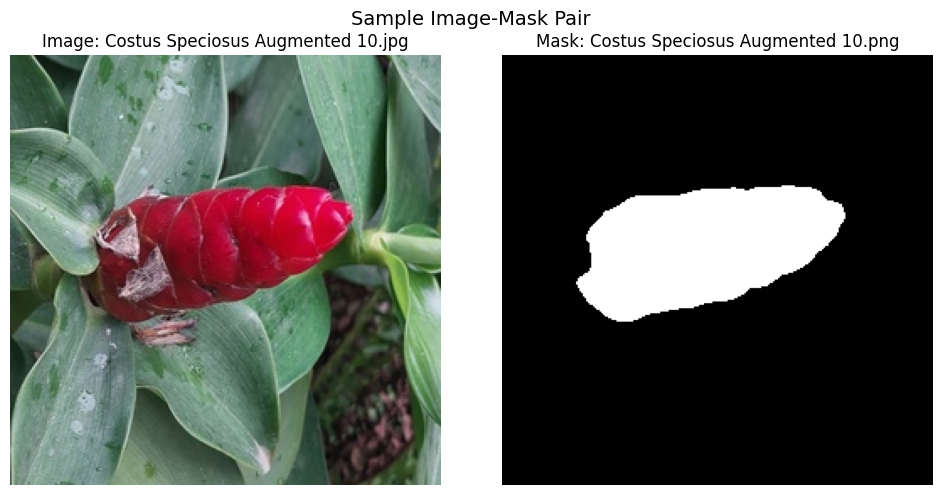

In [5]:
# ==========================================
# 3. INTERACTIVE DATA UPLOAD
# ==========================================
print("\n📁 STEP 1: UPLOAD YOUR DATASET")
print("=" * 70)

# Define folder paths
IMG_DEST = "/content/dataset"
MASK_DEST = "/content/masks"

# Clean previous runs
for d in [IMG_DEST, MASK_DEST]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

print("📁 Folder structure created:")
print(f"   Images will be saved to: {IMG_DEST}")
print(f"   Masks will be saved to: {MASK_DEST}")
print()

# Upload images
print("⬇️" * 30)
print("STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)")
print("⬇️" * 30)
uploaded_img = files.upload()
img_zip = list(uploaded_img.keys())[0]
print(f"✅ Uploaded: {img_zip} ({os.path.getsize(img_zip)/1024/1024:.2f} MB)")

# Upload masks
print("\n" + "⬇️" * 30)
print("STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)")
print("⬇️" * 30)
uploaded_mask = files.upload()
mask_zip = list(uploaded_mask.keys())[0]
print(f"✅ Uploaded: {mask_zip} ({os.path.getsize(mask_zip)/1024/1024:.2f} MB)")

print("\n⏳ Extracting files...")
# Extract images
with zipfile.ZipFile(img_zip, 'r') as zip_ref:
    zip_ref.extractall(IMG_DEST)

# Extract masks
with zipfile.ZipFile(mask_zip, 'r') as zip_ref:
    zip_ref.extractall(MASK_DEST)

print("✅ Extraction complete!")
print(f"📊 Image folder: {len(os.listdir(IMG_DEST))} items")
print(f"📊 Mask folder: {len(os.listdir(MASK_DEST))} items")

# ==========================================
# 4. DATA MATCHING & INSPECTION
# ==========================================
print("\n🔍 STEP 2: MATCHING IMAGES WITH MASKS")
print("=" * 70)

def match_pairs(img_folder, mask_folder):
    """Match image files with corresponding mask files"""
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

    # Get all image files
    img_paths = []
    for ext in valid_exts:
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext}")))
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext.upper()}")))

    img_paths = sorted(img_paths)
    print(f"🔍 Found {len(img_paths)} image files")

    # Match with masks
    pairs = []
    unmatched = []

    for img_p in tqdm(img_paths, desc="Matching files"):
        stem = img_p.stem
        # Try to find matching mask
        mask_found = False
        for ext in valid_exts:
            mask_path = Path(mask_folder) / f"{stem}{ext}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break
            # Also check uppercase extension
            mask_path = Path(mask_folder) / f"{stem}{ext.upper()}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break

        if not mask_found:
            unmatched.append(str(img_p))

    return pairs, unmatched

# Match pairs
pairs, unmatched = match_pairs(IMG_DEST, MASK_DEST)

print("\n" + "=" * 70)
print("📊 DATA SUMMARY")
print("=" * 70)
print(f"✅ Successfully matched: {len(pairs)} pairs")
print(f"⚠️  Unmatched images: {len(unmatched)}")

if len(unmatched) > 0:
    print("\n❌ Unmatched files (first 5):")
    for f in unmatched[:5]:
        print(f"   - {Path(f).name}")
    if len(unmatched) > 5:
        print(f"   ... and {len(unmatched)-5} more")

if len(pairs) == 0:
    raise ValueError("❌ CRITICAL ERROR: No image-mask pairs found!")

# Display sample pair
if len(pairs) > 0:
    print("\n🔍 Sample matched pair:")
    img_path, mask_path = pairs[0]
    print(f"   Image: {Path(img_path).name}")
    print(f"   Mask: {Path(mask_path).name}")

    # Show sample image and mask
    try:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        axes[0].imshow(img)
        axes[0].set_title(f"Image: {Path(img_path).name}")
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title(f"Mask: {Path(mask_path).name}")
        axes[1].axis('off')

        plt.suptitle("Sample Image-Mask Pair", fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Could not display sample: {e}")

print("=" * 70)


In [6]:
# ==========================================
# 5. DATASET CLASS DEFINITION
# ==========================================
print("\n📊 STEP 3: PREPARING DATASET FOR SEMI-SUPERVISED LEARNING")
print("=" * 70)

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

class FlowerDataset(Dataset):
    """PyTorch Dataset for flower segmentation"""

    def __init__(self, pairs, image_size=256, train=True):
        """
        Args:
            pairs: List of (image_path, mask_path) tuples
            image_size: Size to resize images to (square)
            train: If True, apply data augmentation
        """
        self.pairs = pairs
        self.image_size = image_size
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get paths
        img_path, mask_path = self.pairs[idx]

        # Load image and mask
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        # Data augmentation (only during training)
        if self.train and random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # Convert to tensors
        img_tensor = TF.to_tensor(img)  # Shape: [3, H, W]
        mask_tensor = TF.to_tensor(mask)  # Shape: [1, H, W]

        # Convert mask to binary (0 or 1)
        mask_tensor = (mask_tensor > 0.5).float()

        return img_tensor, mask_tensor

# Create full dataset
full_dataset = FlowerDataset(pairs, image_size=256, train=True)


📊 STEP 3: PREPARING DATASET FOR SEMI-SUPERVISED LEARNING


In [7]:
# ==========================================
# 6. SEMI-SUPERVISED DATA SPLITS
# ==========================================
print("\n📊 Creating semi-supervised splits...")

# Total indices
indices = list(range(len(pairs)))
random.shuffle(indices)

n_total = len(indices)
n_train = int(0.8 * n_total)  # 80% for training
n_val = int(0.1 * n_total)    # 10% for validation
n_test = n_total - n_train - n_val  # 10% for testing

# Split indices
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

# Within training: 20% labeled, 80% unlabeled (for semi-supervised)
n_labeled = int(0.2 * len(train_idx))
labeled_idx = train_idx[:n_labeled]
unlabeled_idx = train_idx[n_labeled:]

print("\n📊 SEMI-SUPERVISED DATASET SPLITS")
print("=" * 70)
print(f"Total pairs: {n_total}")
print(f"Training (80%): {n_train} images")
print(f"  → Labeled (20%): {n_labeled} images")
print(f"  → Unlabeled (80%): {len(unlabeled_idx)} images")
print(f"Validation (10%): {n_val} images")
print(f"Test (10%): {n_test} images")
print("=" * 70)

# Create subsets
labeled_ds = Subset(full_dataset, labeled_idx)
unlabeled_ds = Subset(full_dataset, unlabeled_idx)

# Validation dataset (no augmentation)
val_dataset = FlowerDataset([pairs[i] for i in val_idx], image_size=256, train=False)
test_dataset = FlowerDataset([pairs[i] for i in test_idx], image_size=256, train=False)

# DataLoaders
labeled_dl = DataLoader(
    labeled_ds,
    batch_size=LABELED_BATCH,
    shuffle=True,
    num_workers=0,  # Colab compatibility
    pin_memory=True,
    drop_last=True
)

unlabeled_dl = DataLoader(
    unlabeled_ds,
    batch_size=UNLABELED_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_dl = DataLoader(
    val_dataset,
    batch_size=LABELED_BATCH * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_dl = DataLoader(
    test_dataset,
    batch_size=LABELED_BATCH * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("✅ Data loaders created successfully!")


📊 Creating semi-supervised splits...

📊 SEMI-SUPERVISED DATASET SPLITS
Total pairs: 7397
Training (80%): 5917 images
  → Labeled (20%): 1183 images
  → Unlabeled (80%): 4734 images
Validation (10%): 739 images
Test (10%): 741 images
✅ Data loaders created successfully!


In [8]:
# ==========================================
# 7. DEEPLABV3+ MODEL DEFINITION FOR MEAN TEACHER
# ==========================================
print("\n🤖 STEP 4: BUILDING DEEPLABV3+ MODEL FOR MEAN TEACHER")
print("=" * 70)

class DeepLabV3PlusMT(nn.Module):
    """DeepLabV3+ model for Mean Teacher framework"""
    def __init__(self, num_classes=1):
        super().__init__()
        # Load pre-trained DeepLabV3+
        self.model = models.segmentation.deeplabv3_resnet50(
            weights='DEFAULT',
            weights_backbone='DEFAULT'
        )
        # Modify for binary segmentation
        self.model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
        self.model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x, return_both=False):
        output = self.model(x)
        if return_both:
            return output['out'], output['aux']
        return output['out']

    def predict(self, x):
        """Forward pass for inference"""
        with torch.no_grad():
            output = self.model(x)
            return torch.sigmoid(output['out'])

def get_deeplabv3_mt():
    """Create DeepLabV3+ model for Mean Teacher"""
    model = DeepLabV3PlusMT(num_classes=1).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"✅ DeepLabV3+ Mean Teacher model created")
    print(f"   Parameters: {total_params:,}")
    print(f"   Device: {next(model.parameters()).device}")
    return model



🤖 STEP 4: BUILDING DEEPLABV3+ MODEL FOR MEAN TEACHER


In [9]:
# ==========================================
# 8. MEAN TEACHER TRAINING PIPELINE
# ==========================================
print("\n" + "=" * 70)
print("🎓 STEP 5: TRAINING MEAN TEACHER WITH DEEPLABV3+")
print("=" * 70)

# 1. INITIALIZE STUDENT AND TEACHER
print("\n📌 Initializing Student and Teacher models...")
student_model = get_deeplabv3_mt()
teacher_model = get_deeplabv3_mt()

# Initialize teacher with student weights
teacher_model.load_state_dict(student_model.state_dict())

# Freeze teacher parameters
for param in teacher_model.parameters():
    param.requires_grad = False

# 2. OPTIMIZER AND LOSS FUNCTIONS
print("📌 Setting up optimizer and loss functions...")
optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Supervised loss (combined main + auxiliary)
class DeepLabSupervisedLoss(nn.Module):
    def __init__(self, aux_weight=0.4):
        super().__init__()
        self.aux_weight = aux_weight
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, outputs, targets):
        if isinstance(outputs, tuple):
            main_out, aux_out = outputs
            main_loss = self.bce_loss(main_out, targets)
            aux_loss = self.bce_loss(aux_out, targets)
            return main_loss + self.aux_weight * aux_loss
        return self.bce_loss(outputs, targets)

criterion_supervised = DeepLabSupervisedLoss(aux_weight=0.4)
criterion_consistency = nn.MSELoss()

# 3. TEACHER UPDATE FUNCTION
def update_teacher(student, teacher, alpha=0.999):
    """Exponential Moving Average (EMA) update"""
    with torch.no_grad():
        for s_param, t_param in zip(student.parameters(), teacher.parameters()):
            t_param.data.mul_(alpha).add_(s_param.data * (1 - alpha))

# 4. DATA AUGMENTATION FOR CONSISTENCY
def add_consistency_noise(images, noise_std=0.05):
    """Add Gaussian noise for consistency training"""
    noise = torch.randn_like(images) * noise_std
    return images + noise

# 5. METRICS FUNCTION
def calculate_metrics(pred, target, threshold=0.5):
    """Calculate IoU and Dice metrics"""
    pred_prob = torch.sigmoid(pred)
    pred_binary = (pred_prob > threshold).float()

    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)

    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum()

    iou = intersection / (union - intersection + 1e-6)
    dice = (2. * intersection) / (union + 1e-6)

    return dice.item(), iou.item()

# 6. TRAINING PARAMETERS
NUM_EPOCHS = 30
CONSISTENCY_WEIGHT = 0.5
EMA_ALPHA = 0.999
NOISE_STD = 0.05

# Mixed precision training
scaler = torch.cuda.amp.GradScaler()

# Warmup scheduler
def get_warmup_scheduler(optimizer, warmup_epochs=5, total_epochs=30):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch) / float(max(1, warmup_epochs))
        else:
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return max(0.0, 1.0 - progress)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_warmup_scheduler(optimizer, warmup_epochs=5, total_epochs=NUM_EPOCHS)

# 7. TRAINING LOOP
print("\n🔥 Starting Mean Teacher training...")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Consistency weight: {CONSISTENCY_WEIGHT}")
print(f"   EMA alpha: {EMA_ALPHA}")
print("=" * 70)

# History tracking
mt_history = {
    'train_loss': [],
    'sup_loss': [],
    'cons_loss': [],
    'val_dice': [],
    'val_iou': []
}

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    student_model.train()
    teacher_model.train()  # Teacher in train mode for BN stats

    # Initialize iterators
    iter_labeled = iter(labeled_dl)
    iter_unlabeled = iter(unlabeled_dl)

    epoch_loss = 0
    epoch_sup_loss = 0
    epoch_cons_loss = 0

    # Training loop
    pbar = tqdm(range(len(labeled_dl)), desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)

    for step in pbar:
        try:
            l_imgs, l_masks = next(iter_labeled)
        except StopIteration:
            iter_labeled = iter(labeled_dl)
            l_imgs, l_masks = next(iter_labeled)

        try:
            u_imgs, _ = next(iter_unlabeled)
        except StopIteration:
            iter_unlabeled = iter(unlabeled_dl)
            u_imgs, _ = next(iter_unlabeled)

        # Move to device
        l_imgs, l_masks = l_imgs.to(DEVICE), l_masks.to(DEVICE)
        u_imgs = u_imgs.to(DEVICE)

        # ===== SUPERVISED LOSS =====
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            # Student forward on labeled data
            student_main, student_aux = student_model(l_imgs, return_both=True)
            sup_loss = criterion_supervised((student_main, student_aux), l_masks)

        # ===== CONSISTENCY LOSS =====
        with torch.cuda.amp.autocast():
            # Add noise to unlabeled images
            u_imgs_noisy = add_consistency_noise(u_imgs, noise_std=NOISE_STD)

            # Student prediction on noisy unlabeled data
            student_u_main, student_u_aux = student_model(u_imgs_noisy, return_both=True)
            student_u_probs = torch.sigmoid(student_u_main)

            # Teacher prediction on clean unlabeled data (no gradient)
            with torch.no_grad():
                teacher_u_main, _ = teacher_model(u_imgs, return_both=True)
                teacher_u_probs = torch.sigmoid(teacher_u_main).detach()

            # Consistency loss (MSE between probabilities)
            cons_loss = criterion_consistency(student_u_probs, teacher_u_probs)

        # ===== TOTAL LOSS =====
        # Ramp up consistency weight
        if epoch < 10:
            current_weight = CONSISTENCY_WEIGHT * (epoch + 1) / 10
        else:
            current_weight = CONSISTENCY_WEIGHT

        total_loss = sup_loss + current_weight * cons_loss

        # Backward pass with gradient scaling
        scaler.scale(total_loss).backward()

        # Gradient clipping for stability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)

        # Optimizer step
        scaler.step(optimizer)
        scaler.update()

        # Update teacher with EMA
        update_teacher(student_model, teacher_model, alpha=EMA_ALPHA)

        # Track losses
        epoch_loss += total_loss.item()
        epoch_sup_loss += sup_loss.item()
        epoch_cons_loss += cons_loss.item()

        pbar.set_postfix({
            'sup': f'{sup_loss.item():.4f}',
            'cons': f'{cons_loss.item():.4f}',
            'weight': f'{current_weight:.3f}'
        })

    # Update learning rate
    scheduler.step()

    # ===== VALIDATION =====
    teacher_model.eval()
    val_dice_total, val_iou_total = 0, 0

    with torch.no_grad():
        for val_imgs, val_masks in val_dl:
            val_imgs, val_masks = val_imgs.to(DEVICE), val_masks.to(DEVICE)

            # Use teacher for validation
            teacher_output, _ = teacher_model(val_imgs, return_both=True)
            dice, iou = calculate_metrics(teacher_output, val_masks)

            val_dice_total += dice
            val_iou_total += iou

    # Calculate averages
    avg_loss = epoch_loss / len(labeled_dl)
    avg_sup_loss = epoch_sup_loss / len(labeled_dl)
    avg_cons_loss = epoch_cons_loss / len(labeled_dl)
    avg_val_dice = val_dice_total / len(val_dl)
    avg_val_iou = val_iou_total / len(val_dl)

    # Store history
    mt_history['train_loss'].append(avg_loss)
    mt_history['sup_loss'].append(avg_sup_loss)
    mt_history['cons_loss'].append(avg_cons_loss)
    mt_history['val_dice'].append(avg_val_dice)
    mt_history['val_iou'].append(avg_val_iou)

    # Print epoch summary
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Loss: {avg_loss:.4f} (Sup: {avg_sup_loss:.4f}, Cons: {avg_cons_loss:.4f}) | "
          f"Val Dice: {avg_val_dice:.4f} | Val IoU: {avg_val_iou:.4f} | "
          f"LR: {current_lr:.2e}")

# Calculate total training time
total_time = time.time() - start_time
minutes, seconds = divmod(total_time, 60)
print(f"\n✅ Training completed in {int(minutes)}m {int(seconds)}s!")



🎓 STEP 5: TRAINING MEAN TEACHER WITH DEEPLABV3+

📌 Initializing Student and Teacher models...
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 191MB/s]


✅ DeepLabV3+ Mean Teacher model created
   Parameters: 41,993,794
   Device: cuda:0
✅ DeepLabV3+ Mean Teacher model created
   Parameters: 41,993,794
   Device: cuda:0
📌 Setting up optimizer and loss functions...

🔥 Starting Mean Teacher training...
   Epochs: 30
   Consistency weight: 0.5
   EMA alpha: 0.999


Epoch 1/30:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 01/30 | Loss: 0.9953 (Sup: 0.9953, Cons: 0.0008) | Val Dice: 0.2985 | Val IoU: 0.1792 | LR: 2.00e-05


...

Epoch 28/30 | Loss: 0.0550 (Sup: 0.0528, Cons: 0.0043) | Val Dice: 0.6860 | Val IoU: 0.5399 | LR: 8.00e-06


Epoch 29/30:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 29/30 | Loss: 0.0541 (Sup: 0.0521, Cons: 0.0040) | Val Dice: 0.6851 | Val IoU: 0.5393 | LR: 4.00e-06


Epoch 30/30:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 30/30 | Loss: 0.0541 (Sup: 0.0521, Cons: 0.0039) | Val Dice: 0.6872 | Val IoU: 0.5414 | LR: 0.00e+00

✅ Training completed in 55m 26s!


In [10]:
# ==========================================
# 9. COMPREHENSIVE EVALUATION
# ==========================================
print("\n" + "=" * 70)
print("📊 STEP 6: COMPREHENSIVE EVALUATION")
print("=" * 70)

def get_comprehensive_metrics(pred_logits, target_mask, threshold=0.5):
    """Calculate comprehensive segmentation metrics"""
    # Convert logits to probabilities and binary masks
    probs = torch.sigmoid(pred_logits)
    pred = (probs > threshold).float()

    # Flatten for calculation
    pred_flat = pred.view(-1)
    target_flat = target_mask.view(-1)

    # Calculate confusion matrix components
    TP = (pred_flat * target_flat).sum()
    FP = (pred_flat * (1 - target_flat)).sum()
    FN = ((1 - pred_flat) * target_flat).sum()
    TN = ((1 - pred_flat) * (1 - target_flat)).sum()

    # 1. Intersection over Union (IoU/Jaccard Index)
    iou = TP / (TP + FP + FN + 1e-6)

    # 2. Dice Coefficient (F1 Score)
    dice = (2. * TP) / (2. * TP + FP + FN + 1e-6)

    # 3. Pixel Accuracy
    pixel_acc = (TP + TN) / (TP + FP + FN + TN + 1e-6)

    # 4. Precision
    precision = TP / (TP + FP + 1e-6)

    # 5. Recall (Sensitivity)
    recall = TP / (TP + FN + 1e-6)

    # 6. Specificity
    specificity = TN / (TN + FP + 1e-6)

    # 7. F2 Score (weights recall higher than precision)
    f2_score = (5 * precision * recall) / (4 * precision + recall + 1e-6)

    return {
        'iou': iou.item(),
        'dice': dice.item(),
        'pixel_acc': pixel_acc.item(),
        'precision': precision.item(),
        'recall': recall.item(),
        'specificity': specificity.item(),
        'f2_score': f2_score.item()
    }

# Evaluate on test set
teacher_model.eval()
all_metrics = []

print("\n🧪 Evaluating on test set...")
with torch.no_grad():
    pbar = tqdm(test_dl, desc="Processing test batches")
    for imgs, masks in pbar:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        # Teacher predictions
        outputs, _ = teacher_model(imgs, return_both=True)

        # Calculate metrics
        metrics = get_comprehensive_metrics(outputs, masks)
        all_metrics.append(metrics)

        pbar.set_postfix({'IoU': f'{metrics["iou"]:.3f}', 'Dice': f'{metrics["dice"]:.3f}'})

# Calculate average metrics
avg_metrics = {}
for key in all_metrics[0].keys():
    values = [m[key] for m in all_metrics]
    avg_metrics[key] = np.mean(values)
    avg_metrics[f'{key}_std'] = np.std(values)

print("\n🏆 MEAN TEACHER FINAL RESULTS (DEEPLABV3+):")
print("=" * 70)
print(f"Primary Metrics:")
print(f"  • IoU (Jaccard):          {avg_metrics['iou']:.4f} ± {avg_metrics['iou_std']:.4f}")
print(f"  • Dice Coefficient:       {avg_metrics['dice']:.4f} ± {avg_metrics['dice_std']:.4f}")
print(f"  • Pixel Accuracy:         {avg_metrics['pixel_acc']:.4f} ± {avg_metrics['pixel_acc_std']:.4f}")
print(f"\nSecondary Metrics:")
print(f"  • Precision:              {avg_metrics['precision']:.4f} ± {avg_metrics['precision_std']:.4f}")
print(f"  • Recall (Sensitivity):   {avg_metrics['recall']:.4f} ± {avg_metrics['recall_std']:.4f}")
print(f"  • Specificity:            {avg_metrics['specificity']:.4f} ± {avg_metrics['specificity_std']:.4f}")
print(f"  • F2 Score:               {avg_metrics['f2_score']:.4f} ± {avg_metrics['f2_score_std']:.4f}")


📊 STEP 6: COMPREHENSIVE EVALUATION

🧪 Evaluating on test set...


Processing test batches:   0%|          | 0/24 [00:00<?, ?it/s]


🏆 MEAN TEACHER FINAL RESULTS (DEEPLABV3+):
Primary Metrics:
  • IoU (Jaccard):          0.5653 ± 0.1010
  • Dice Coefficient:       0.7170 ± 0.0826
  • Pixel Accuracy:         0.8993 ± 0.0319

Secondary Metrics:
  • Precision:              0.7217 ± 0.0992
  • Recall (Sensitivity):   0.7234 ± 0.1089
  • Specificity:            0.9387 ± 0.0262
  • F2 Score:               0.7195 ± 0.0946



🎨 STEP 7: VISUALIZING RESULTS

📈 Plotting training curves...


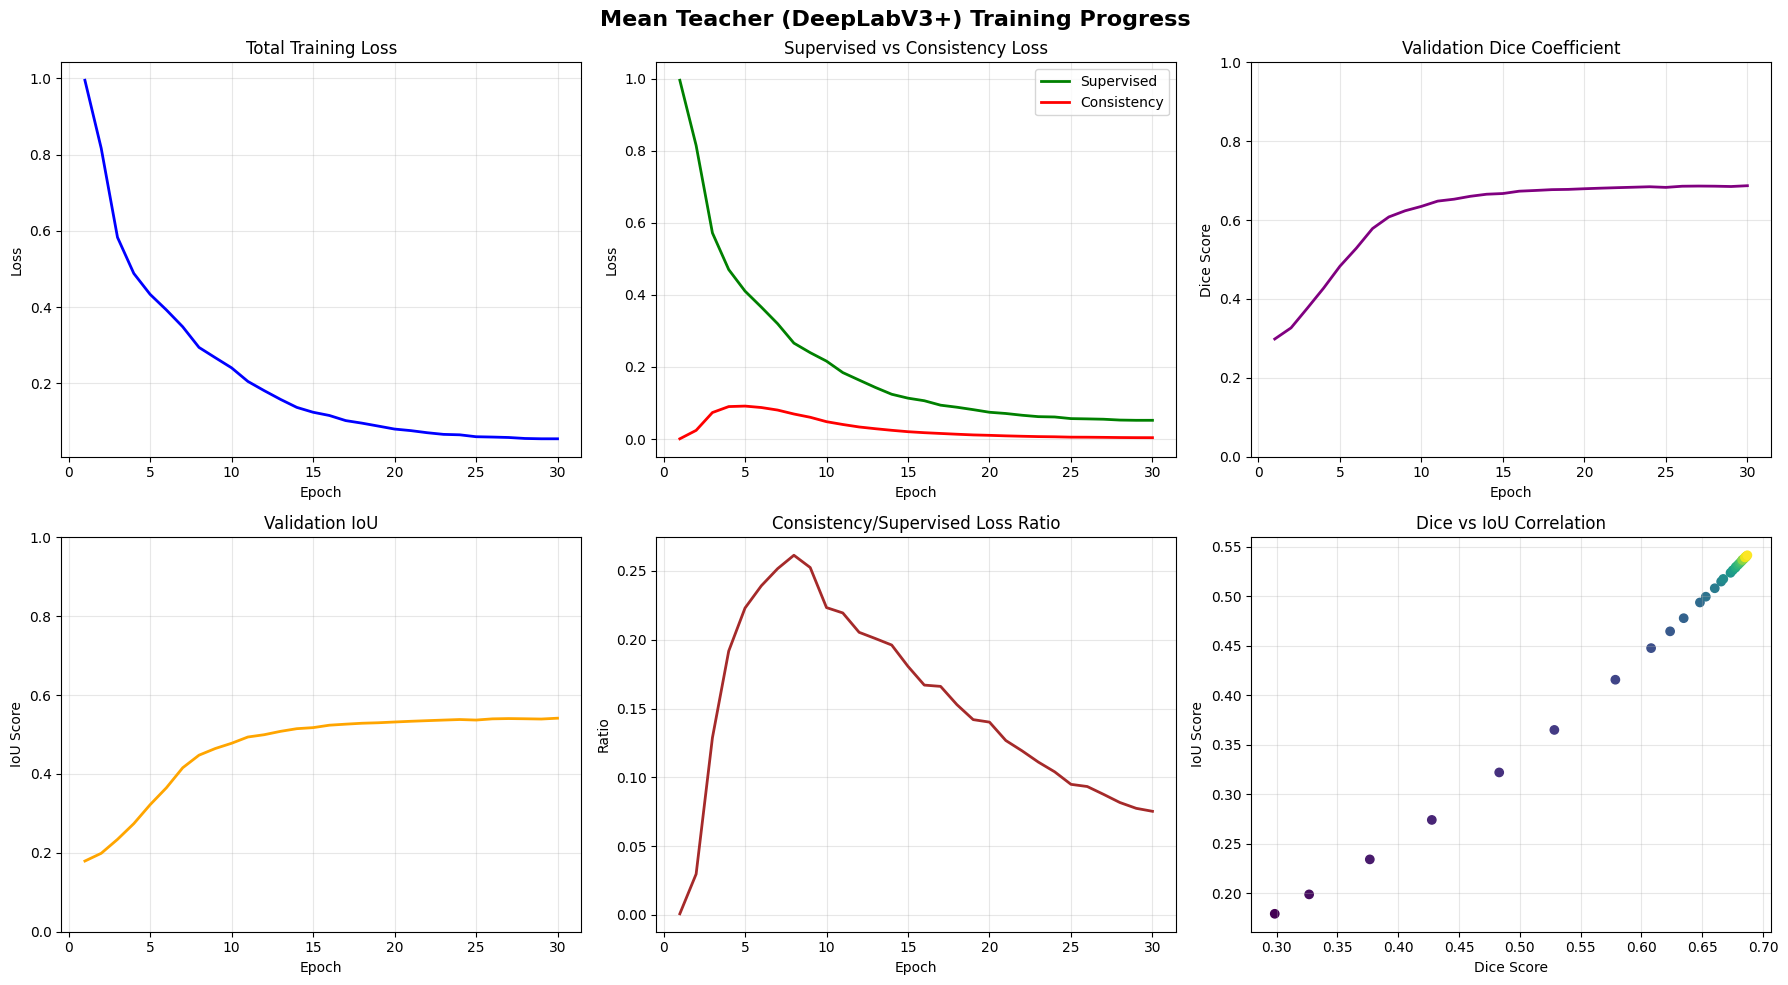


🎨 Visualizing predictions...


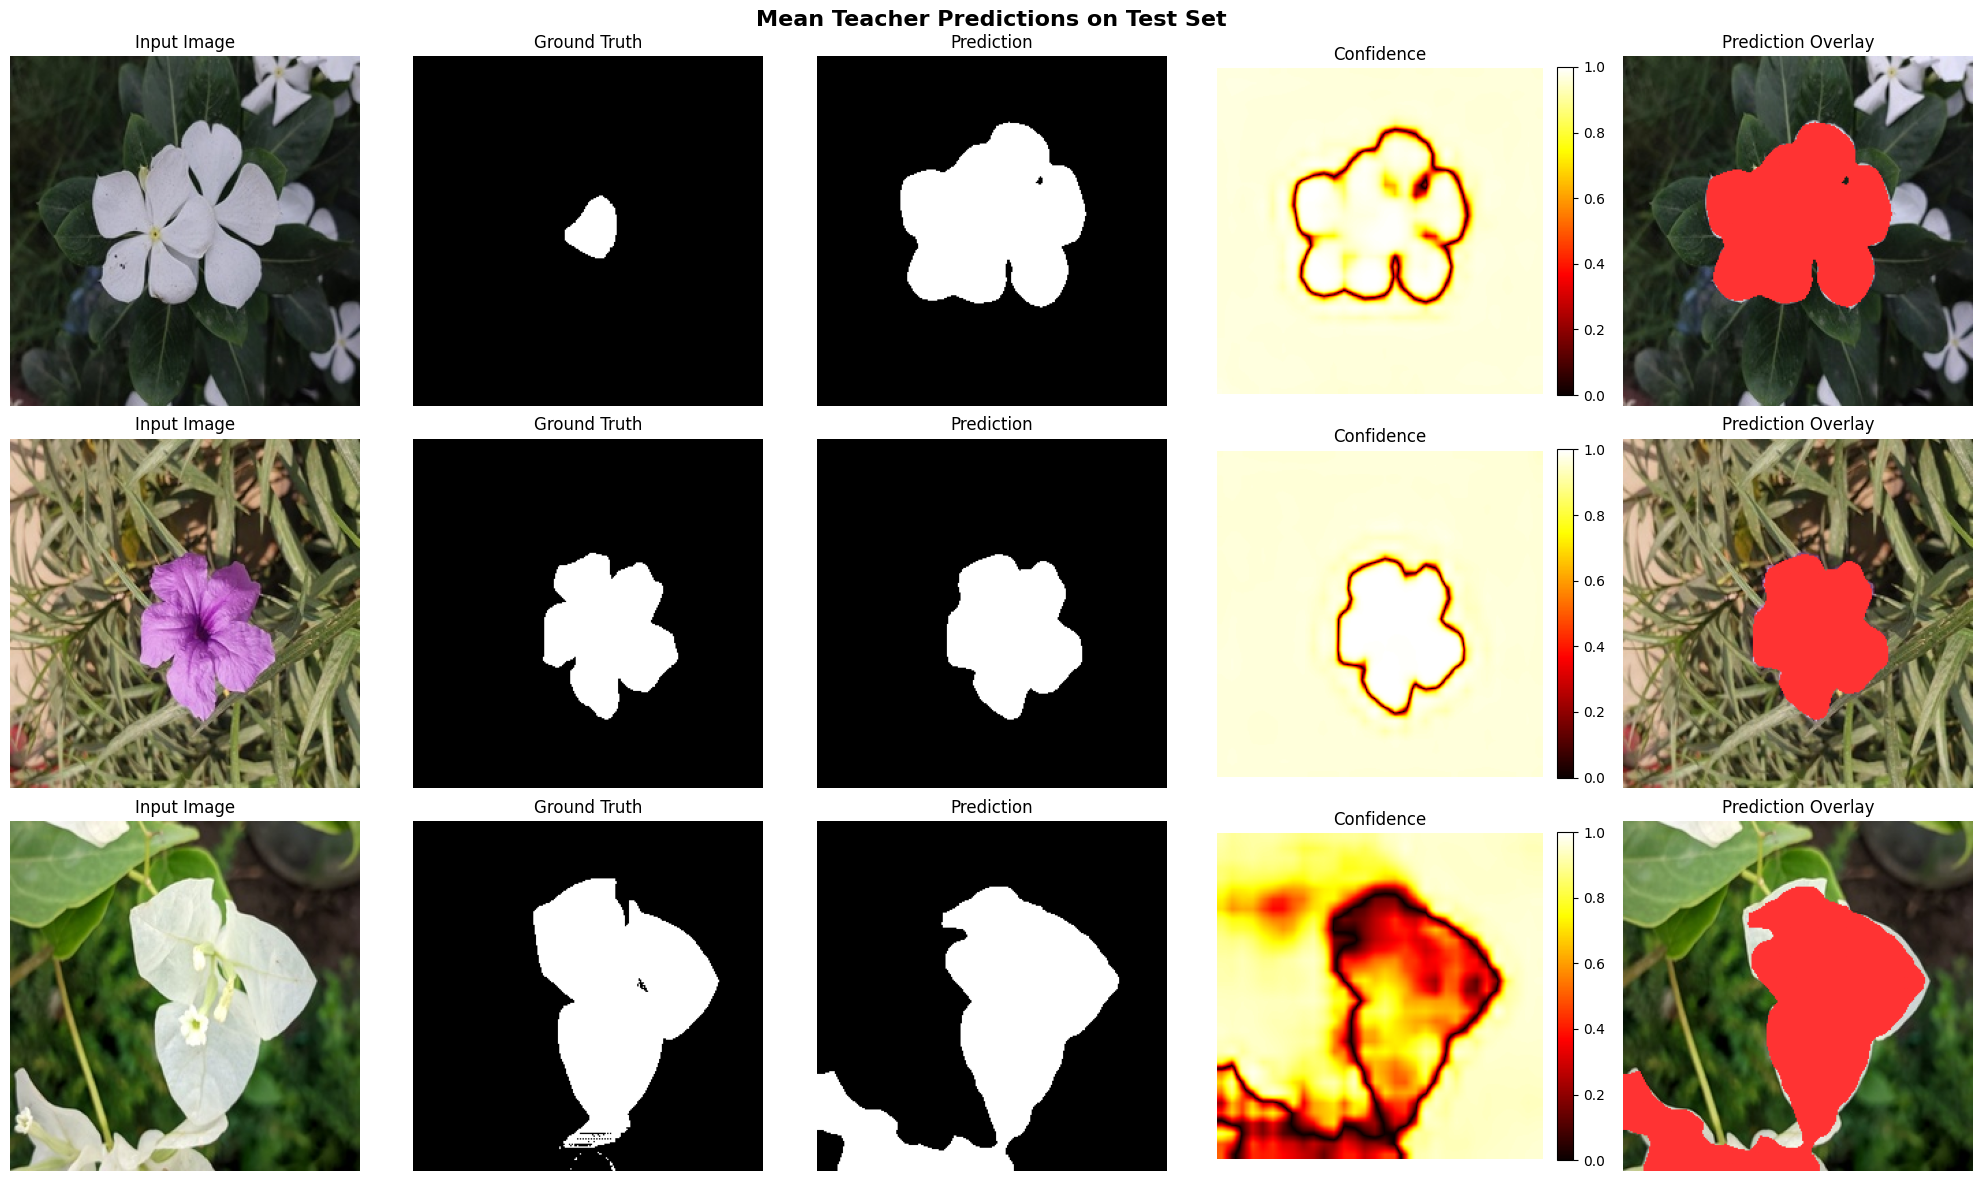

In [11]:
# ==========================================
# 10. VISUALIZATION
# ==========================================
print("\n" + "=" * 70)
print("🎨 STEP 7: VISUALIZING RESULTS")
print("=" * 70)

def plot_training_curves(mt_history):
    """Plot Mean Teacher training curves"""
    epochs = range(1, len(mt_history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Total loss
    axes[0, 0].plot(epochs, mt_history['train_loss'], 'b-', linewidth=2)
    axes[0, 0].set_title('Total Training Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

    # Supervised vs Consistency loss
    axes[0, 1].plot(epochs, mt_history['sup_loss'], 'g-', label='Supervised', linewidth=2)
    axes[0, 1].plot(epochs, mt_history['cons_loss'], 'r-', label='Consistency', linewidth=2)
    axes[0, 1].set_title('Supervised vs Consistency Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Validation Dice
    axes[0, 2].plot(epochs, mt_history['val_dice'], 'purple', linewidth=2)
    axes[0, 2].set_title('Validation Dice Coefficient')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Dice Score')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_ylim([0, 1])

    # Validation IoU
    axes[1, 0].plot(epochs, mt_history['val_iou'], 'orange', linewidth=2)
    axes[1, 0].set_title('Validation IoU')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU Score')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 1])

    # Loss ratio
    loss_ratio = [c/s if s > 0 else 0 for c, s in zip(mt_history['cons_loss'], mt_history['sup_loss'])]
    axes[1, 1].plot(epochs, loss_ratio, 'brown', linewidth=2)
    axes[1, 1].set_title('Consistency/Supervised Loss Ratio')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Ratio')
    axes[1, 1].grid(True, alpha=0.3)

    # Dice vs IoU correlation
    axes[1, 2].scatter(mt_history['val_dice'], mt_history['val_iou'], c=epochs, cmap='viridis')
    axes[1, 2].set_title('Dice vs IoU Correlation')
    axes[1, 2].set_xlabel('Dice Score')
    axes[1, 2].set_ylabel('IoU Score')
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle('Mean Teacher (DeepLabV3+) Training Progress', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, dataloader, num_samples=3):
    """Visualize model predictions"""
    model.eval()

    # Get a batch
    imgs, masks = next(iter(dataloader))

    # Select random samples
    indices = torch.randperm(len(imgs))[:num_samples]

    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))

    for i, idx in enumerate(indices):
        img = imgs[idx].unsqueeze(0).to(DEVICE)
        true_mask = masks[idx].cpu()

        with torch.no_grad():
            # Model predictions
            output, _ = model(img, return_both=True)
            prob = torch.sigmoid(output).cpu()
            pred_mask = (prob > 0.5).float()

            # Confidence map
            confidence = torch.abs(prob - 0.5) * 2

        # Original image
        axes[i, 0].imshow(imgs[idx].permute(1, 2, 0))
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis('off')

        # Ground truth
        axes[i, 1].imshow(true_mask.squeeze(), cmap='gray')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')

        # Prediction
        axes[i, 2].imshow(pred_mask.squeeze(), cmap='gray')
        axes[i, 2].set_title(f"Prediction")
        axes[i, 2].axis('off')

        # Confidence map
        conf_map = axes[i, 3].imshow(confidence.squeeze(), cmap='hot', vmin=0, vmax=1)
        axes[i, 3].set_title("Confidence")
        axes[i, 3].axis('off')
        plt.colorbar(conf_map, ax=axes[i, 3], fraction=0.046, pad=0.04)

        # Overlay
        overlay = imgs[idx].permute(1, 2, 0).numpy()
        overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min())

        # Create overlay with predictions
        pred_overlay = overlay.copy()
        pred_mask_np = pred_mask.squeeze().numpy()

        # Highlight predictions in red
        pred_overlay[pred_mask_np == 1, 0] = 1.0  # Red channel
        pred_overlay[pred_mask_np == 1, 1] = 0.2  # Reduce green
        pred_overlay[pred_mask_np == 1, 2] = 0.2  # Reduce blue

        axes[i, 4].imshow(pred_overlay)
        axes[i, 4].set_title("Prediction Overlay")
        axes[i, 4].axis('off')

    plt.suptitle('Mean Teacher Predictions on Test Set', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Generate visualizations
print("\n📈 Plotting training curves...")
plot_training_curves(mt_history)

print("\n🎨 Visualizing predictions...")
visualize_predictions(teacher_model, test_dl, num_samples=3)

In [12]:
# ==========================================
# 11. SAVE RESULTS & DOWNLOAD
# ==========================================
print("\n" + "=" * 70)
print("💾 STEP 8: SAVING RESULTS")
print("=" * 70)

# Create results directory
results_dir = "/content/mean_teacher_results"
os.makedirs(results_dir, exist_ok=True)

# Save model checkpoints
model_path = os.path.join(results_dir, "mean_teacher_deeplabv3.pth")
torch.save({
    'teacher_state_dict': teacher_model.state_dict(),
    'student_state_dict': student_model.state_dict(),
    'mt_history': mt_history,
    'test_metrics': avg_metrics,
    'config': {
        'model': 'DeepLabV3+',
        'method': 'Mean Teacher',
        'epochs': NUM_EPOCHS,
        'labeled_data': f'{n_labeled} images (20%)',
        'unlabeled_data': f'{len(unlabeled_idx)} images (80%)',
        'consistency_weight': CONSISTENCY_WEIGHT,
        'ema_alpha': EMA_ALPHA,
        'noise_std': NOISE_STD,
        'batch_size': {'labeled': LABELED_BATCH, 'unlabeled': UNLABELED_BATCH}
    }
}, model_path)

print(f"✅ Model saved to: {model_path}")
print(f"📁 File size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

# Save metrics to text file
metrics_path = os.path.join(results_dir, "metrics_summary.txt")
with open(metrics_path, 'w') as f:
    f.write("=" * 70 + "\n")
    f.write("MEAN TEACHER (DEEPLABV3+) RESULTS SUMMARY\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total Training Time: {int(minutes)}m {int(seconds)}s\n\n")

    f.write("DATASET SPLITS:\n")
    f.write(f"  Total pairs: {n_total}\n")
    f.write(f"  Labeled (20%): {n_labeled}\n")
    f.write(f"  Unlabeled (80%): {len(unlabeled_idx)}\n")
    f.write(f"  Validation: {n_val}\n")
    f.write(f"  Test: {n_test}\n\n")

    f.write("PERFORMANCE METRICS (Test Set):\n")
    f.write(f"  IoU (Jaccard):          {avg_metrics['iou']:.4f} ± {avg_metrics['iou_std']:.4f}\n")
    f.write(f"  Dice Coefficient:       {avg_metrics['dice']:.4f} ± {avg_metrics['dice_std']:.4f}\n")
    f.write(f"  Pixel Accuracy:         {avg_metrics['pixel_acc']:.4f} ± {avg_metrics['pixel_acc_std']:.4f}\n")
    f.write(f"  Precision:              {avg_metrics['precision']:.4f} ± {avg_metrics['precision_std']:.4f}\n")
    f.write(f"  Recall (Sensitivity):   {avg_metrics['recall']:.4f} ± {avg_metrics['recall_std']:.4f}\n")
    f.write(f"  Specificity:            {avg_metrics['specificity']:.4f} ± {avg_metrics['specificity_std']:.4f}\n")
    f.write(f"  F2 Score:               {avg_metrics['f2_score']:.4f} ± {avg_metrics['f2_score_std']:.4f}\n")

print(f"✅ Metrics saved to: {metrics_path}")

# Download results
print("\n⬇️ Downloading results...")
try:
    # Create zip file
    shutil.make_archive("/content/mean_teacher_results", 'zip', results_dir)
    files.download("/content/mean_teacher_results.zip")
    print("✅ Results downloaded successfully!")
except Exception as e:
    print(f"⚠️ Could not download automatically. Files are in: {results_dir}")



💾 STEP 8: SAVING RESULTS
✅ Model saved to: /content/mean_teacher_results/mean_teacher_deeplabv3.pth
📁 File size: 321.09 MB
✅ Metrics saved to: /content/mean_teacher_results/metrics_summary.txt

⬇️ Downloading results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Results downloaded successfully!


In [13]:
# ==========================================
# 12. FINAL SUMMARY
# ==========================================
print("\n" + "=" * 70)
print("🎉 MEAN TEACHER PIPELINE COMPLETE!")
print("=" * 70)
print("\n📋 SUMMARY:")
print(f"1. Uploaded and processed {len(pairs)} image-mask pairs")
print(f"2. Created semi-supervised splits: {n_labeled} labeled + {len(unlabeled_idx)} unlabeled")
print(f"3. Trained Mean Teacher with DeepLabV3+ for {NUM_EPOCHS} epochs")
print(f"4. Achieved test IoU: {avg_metrics['iou']:.4f} ± {avg_metrics['iou_std']:.4f}")
print(f"5. All results saved to: {results_dir}")
print("\n💡 Next steps:")
print("   • Compare with other semi-supervised methods")
print("   • Fine-tune hyperparameters for your specific dataset")
print("   • Deploy the trained model for inference")
print("=" * 70)


🎉 MEAN TEACHER PIPELINE COMPLETE!

📋 SUMMARY:
1. Uploaded and processed 7397 image-mask pairs
2. Created semi-supervised splits: 1183 labeled + 4734 unlabeled
3. Trained Mean Teacher with DeepLabV3+ for 30 epochs
4. Achieved test IoU: 0.5653 ± 0.1010
5. All results saved to: /content/mean_teacher_results

💡 Next steps:
   • Compare with other semi-supervised methods
   • Fine-tune hyperparameters for your specific dataset
   • Deploy the trained model for inference
